In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import medmnist
from medmnist import INFO, Evaluator
from medmnist import DermaMNIST

from torchvision import transforms
from torch.utils.data import DataLoader

In [2]:
data_set = "dermamnist"
download = True

info = INFO[data_set]
task = info["task"] 
n_channels = info["n_channels"]
n_classes = len(info["label"])  
print(f"Task: {task}, Channels: {n_channels}, Number of classes: {n_classes}")

# change sizes here for different resolutions
train_dataset = DermaMNIST(split="train", download=True, size=28)
val_dataset = DermaMNIST(split="val", download=True, size=28)
test_dataset = DermaMNIST(split="test", download=True, size=28)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Task: multi-class, Channels: 3, Number of classes: 7
Using downloaded and verified file: /Users/harshi/.medmnist/dermamnist.npz
Using downloaded and verified file: /Users/harshi/.medmnist/dermamnist.npz
Using downloaded and verified file: /Users/harshi/.medmnist/dermamnist.npz
Number of training images: 7007
Number of validation images: 1003
Number of test images: 2005


In [3]:
class_names = [info["label"][str(i)] for i in range(n_classes)]
datasets = [train_dataset, val_dataset, test_dataset]
dataset_names = ["train", "validation", "test"]

total_counter = Counter()
split_counters = {}

for i in range(3):
    count_labels = [int(label) for _, label in datasets[i]]
    class_counts = Counter(count_labels)
    
    split_name = dataset_names[i]
    split_counters[split_name] = class_counts
    
    total_counter += class_counts

    print(f"[{split_name}] number of images per class:")
    print("-----")
    for j in range(n_classes):   
        count = class_counts[j]
        print(f"{class_names[j]}: {count}")
    print("-----")

total_images = sum(total_counter.values())
print("[total] number and proportions of images per class:")
print("-----")
for j in range(n_classes):
    count = total_counter[j]
    proportion = count / total_images
    print(f"{class_names[j]}: {count} ({proportion:.2%})")
print("-----")

rows = []
for j in range(n_classes):
    row = {
        "class": class_names[j],
        "train": split_counters["train"][j],
        "validation": split_counters["validation"][j],
        "test": split_counters["test"][j],
        "total": total_counter[j],
        "proportion": total_counter[j] / total_images
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

[train] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 228
basal cell carcinoma: 359
benign keratosis-like lesions: 769
dermatofibroma: 80
melanoma: 779
melanocytic nevi: 4693
vascular lesions: 99
-----
[validation] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 33
basal cell carcinoma: 52
benign keratosis-like lesions: 110
dermatofibroma: 12
melanoma: 111
melanocytic nevi: 671
vascular lesions: 14
-----
[test] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 66
basal cell carcinoma: 103
benign keratosis-like lesions: 220
dermatofibroma: 23
melanoma: 223
melanocytic nevi: 1341
vascular lesions: 29
-----
[total] number and proportions of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 327 (3.27%)
basal cell carcinoma: 514 (5.13%)
benign keratosis-like lesions: 1099 (10.97%)
dermatofibroma: 115 (1.15%)
melanoma: 1113 (11.11%)
melanocytic nevi: 6705 (66.95%)
v

,class,train,validation,test,total,proportion
0,actinic keratoses and intraepithelial carcinoma,228,33,66,327,0.032651
1,basal cell carcinoma,359,52,103,514,0.051323
2,benign keratosis-like lesions,769,110,220,1099,0.109735
3,dermatofibroma,80,12,23,115,0.011483
4,melanoma,779,111,223,1113,0.111133
5,melanocytic nevi,4693,671,1341,6705,0.669496
6,vascular lesions,99,14,29,142,0.014179


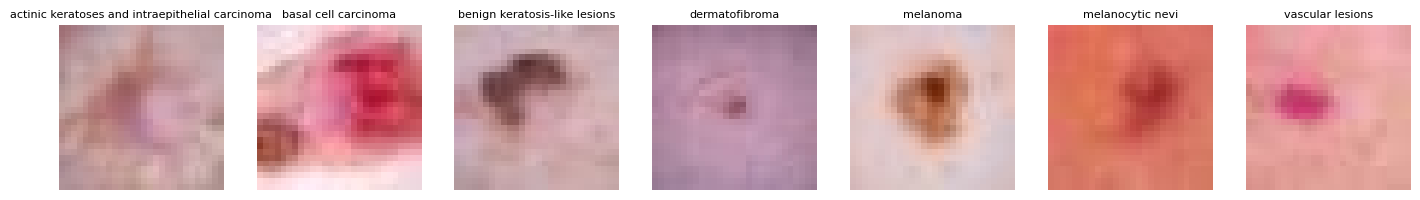

In [4]:
def show_one_per_class(dataset, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))

    if n_classes == 1:
        axes = [axes]
    
    shown_classes = set()
    for img, label in dataset:
        class_idx = int(label)
        
        if class_idx not in shown_classes:
            ax = axes[class_idx]
            
            if hasattr(img, "numpy"): 
                img_np = img.permute(1, 2, 0).numpy()
            else:  
                img_np = np.array(img)
            
            ax.imshow(img_np)
            ax.set_title(class_names[class_idx], fontsize=8)
            ax.axis("off")
            shown_classes.add(class_idx)
        
        if len(shown_classes) == n_classes:
            break

    plt.tight_layout()
    plt.show()

show_one_per_class(train_dataset, class_names)

In [5]:
# data imbalanced, nevi dominate with small counts for other classes
# benign classes: nevi, benign keratosis, dermatofibroma, vascular lesions
# malignant classes: melanoma, basal cell carcinoma
# pre-malignant / early stage: actinic keratoses and intraepithelial carcinoma